In [1]:
!pip install geopandas gender-guesser openpyxl --quiet

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from IPython.display import display
import gender_guesser.detector as gender
from ast import literal_eval
import pandas as pd

In [3]:
plt.rcParams['figure.figsize'] = (16, 9)

# ======================================================================
# 1. Load data from Excel
# ======================================================================
df = pd.read_excel('../data/dimensions/api/raw/combined/202511/df_dimensions.xlsx', index_col=0)



# Ensure 'year' exists and is numeric
if 'year' not in df.columns:
    raise ValueError("'year' column not found in the dataset.")
df['year'] = pd.to_numeric(df['year'], errors='coerce')

Speed of growth/world map


Exploded (paper, year, country) table:


,id,year,research_org_country_names,country
0,pub.1142697354,2021,"['China', 'Australia']",China
0,pub.1142697354,2021,"['China', 'Australia']",Australia
1,pub.1107515670,2018,"['United Kingdom', 'Norway']",United Kingdom
1,pub.1107515670,2018,"['United Kingdom', 'Norway']",Norway
2,pub.1111460082,2019,"['United States', 'United Kingdom']",United States



Top countries by number of UKBB publications:


,country,n_pubs
117,United States,4228
116,United Kingdom,4205
21,China,3666
3,Australia,1269
106,Sweden,955
39,Germany,944
75,Netherlands,942
19,Canada,722
28,Denmark,520
36,France,487


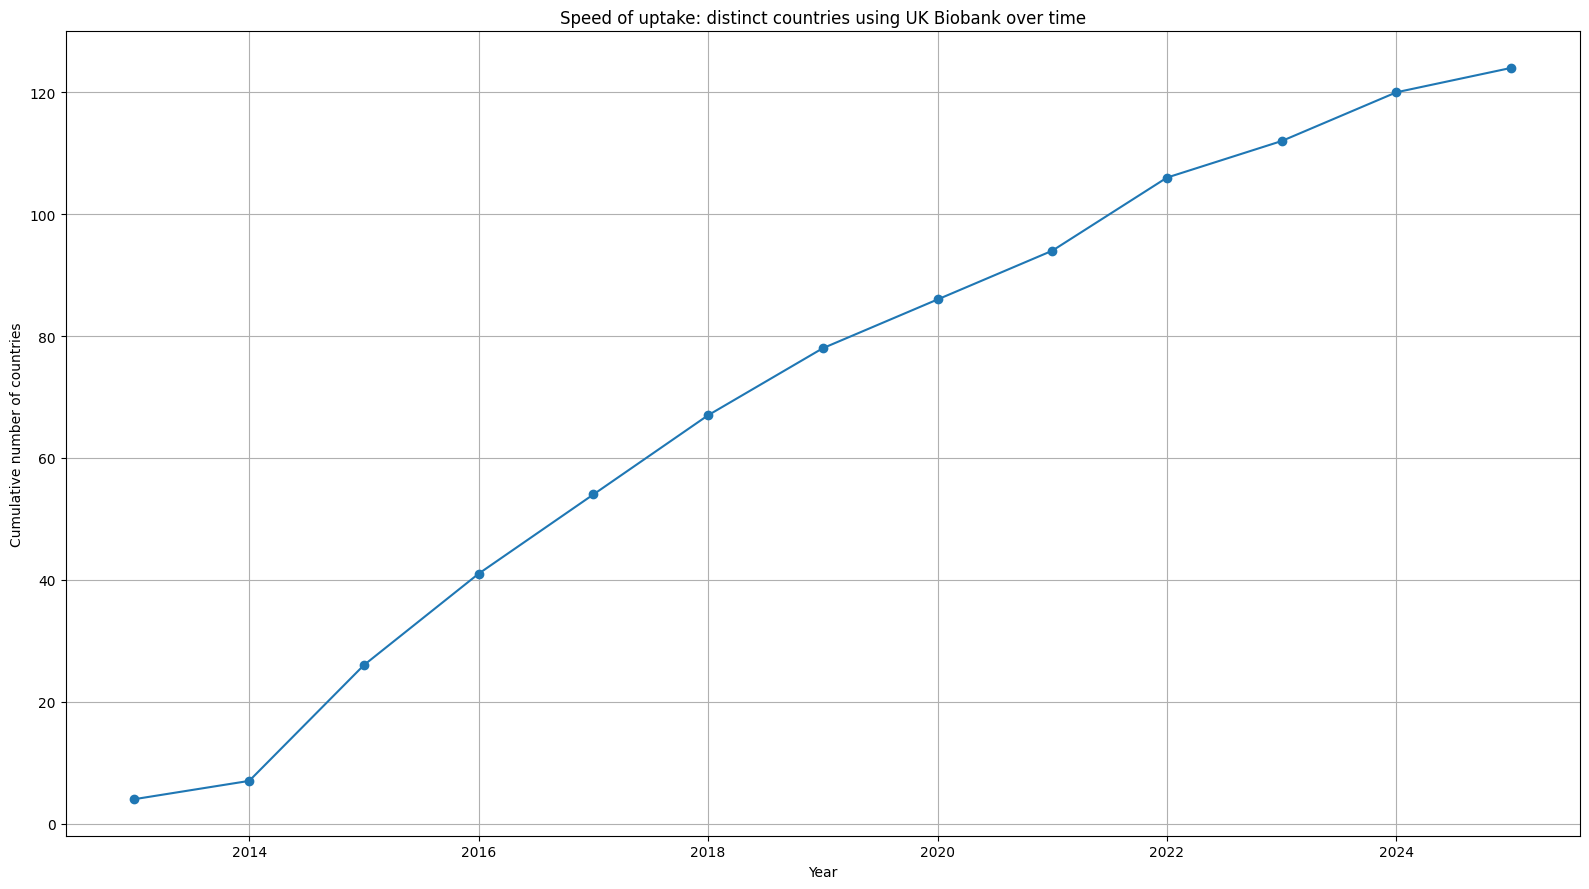

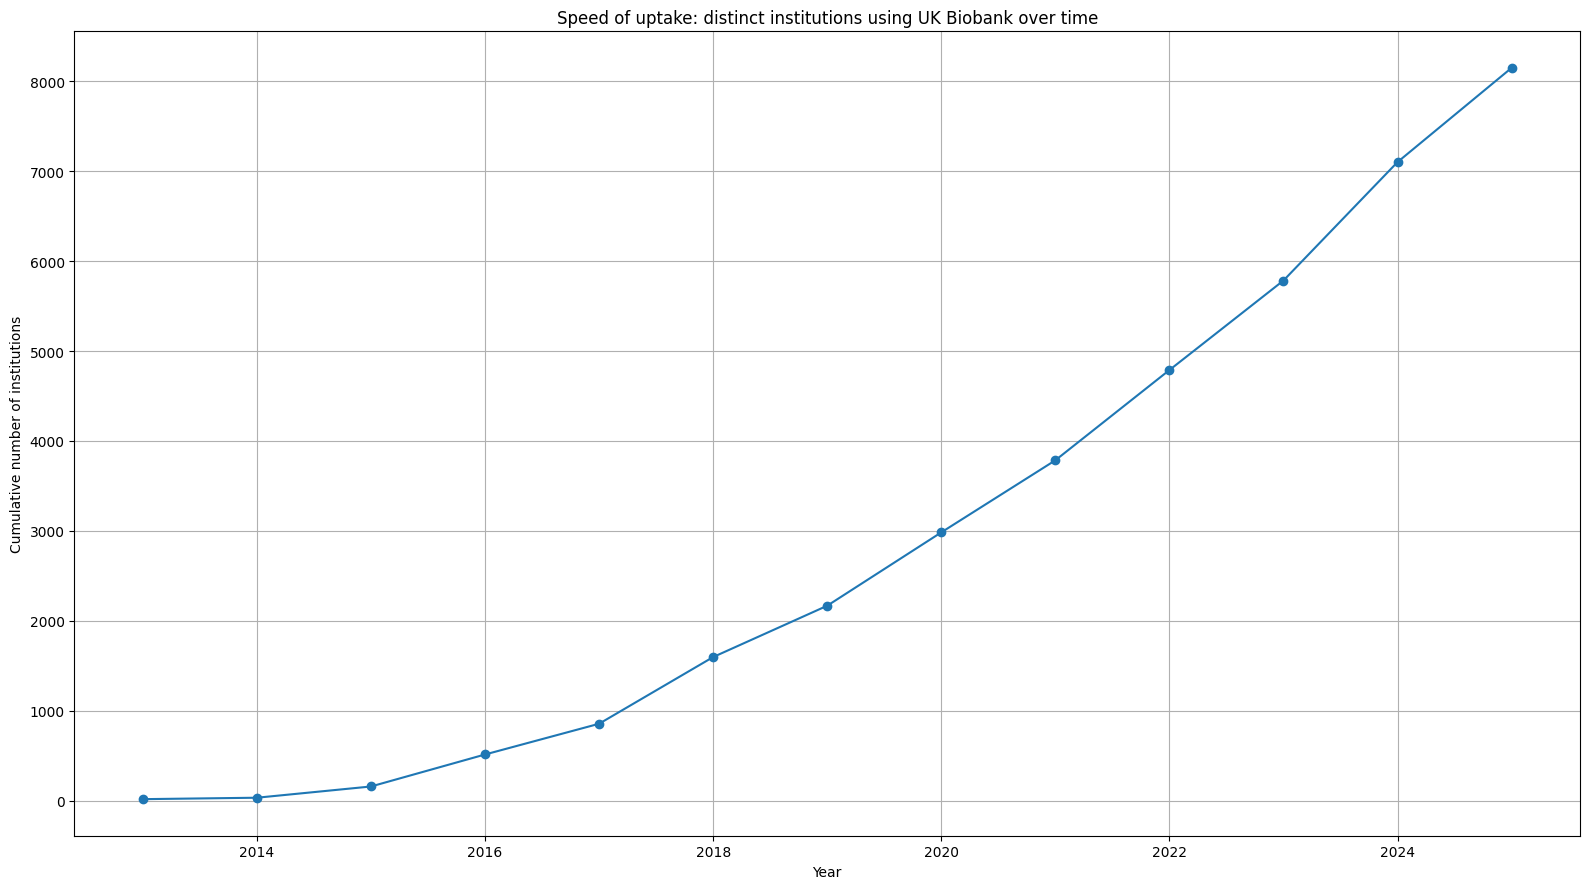


World shapefile example:


,ADMIN,ISO_A3_EH
0,Fiji,FJI
1,United Republic of Tanzania,TZA
2,Western Sahara,ESH
3,Canada,CAN
4,United States of America,USA


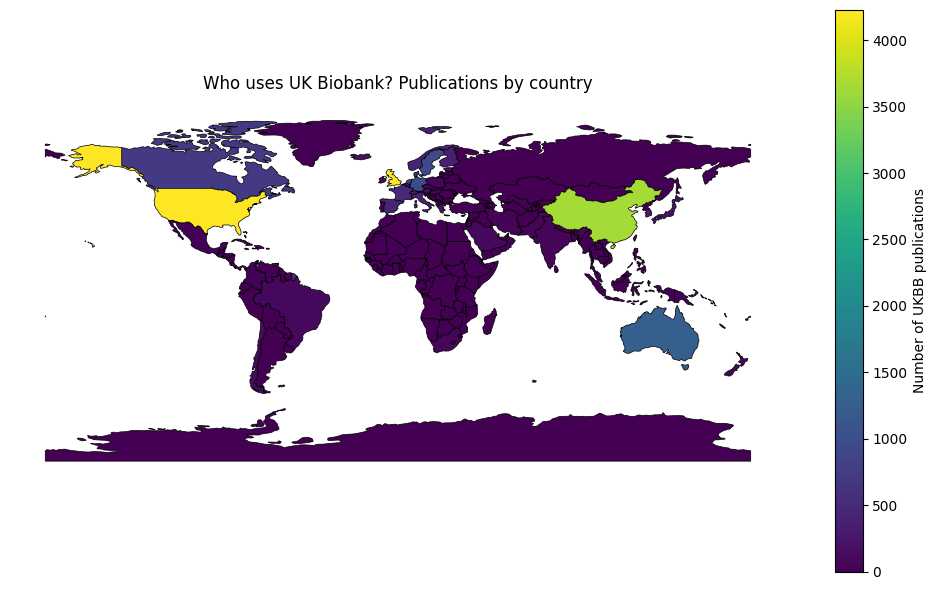

In [4]:




# ======================================================================
# 2. Helper for list-like columns (countries, org names)
# ======================================================================
def split_list_field(value):

    if pd.isna(value):
        return []
    s = str(value)

    # Try to parse as Python literal list
    try:
        parsed = literal_eval(s)
        if isinstance(parsed, (list, tuple)):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass

    # Fallback: split on common delimiters
    for sep in [';', '|']:
        if sep in s:
            return [x.strip() for x in s.split(sep) if x.strip()]

    # Last resort: single value
    s = s.strip()
    return [s] if s else []


# ======================================================================
# 3. "Who uses UKBB?" – countries + speed of uptake
# ======================================================================
if 'research_org_country_names' not in df.columns:
    raise ValueError("'research_org_country_names' column not found in the dataset.")

countries_df = (
    df[['id', 'year', 'research_org_country_names']]
    .assign(country_list=lambda d: d['research_org_country_names'].apply(split_list_field))
    .explode('country_list')
    .rename(columns={'country_list': 'country'})
)

countries_df = countries_df.dropna(subset=['country', 'year'])
countries_df['year'] = countries_df['year'].astype(int)

print("\nExploded (paper, year, country) table:")
display(countries_df.head())

# ----------------------------------------------------------------------
# 3.1 Country-level counts for choropleth
# ----------------------------------------------------------------------
country_counts = (
    countries_df
    .groupby('country')
    .agg(n_pubs=('id', 'nunique'))
    .reset_index()
    .sort_values('n_pubs', ascending=False)
)

print("\nTop countries by number of UKBB publications:")
display(country_counts.head(10))

# ----------------------------------------------------------------------
# 3.2 Speed of uptake: cumulative count of distinct countries over time
# ----------------------------------------------------------------------
year_country = (
    countries_df[['year', 'country']]
    .drop_duplicates()
    .sort_values(['year', 'country'])
)

years = sorted(year_country['year'].unique())
cum_counts = []
seen = set()

for y in years:
    subset = year_country[year_country['year'] == y]['country']
    seen.update(subset)
    cum_counts.append({'year': y, 'cum_countries': len(seen)})

uptake_df = pd.DataFrame(cum_counts)

plt.figure()
plt.plot(uptake_df['year'], uptake_df['cum_countries'], marker='o')
plt.xlabel('Year')
plt.ylabel('Cumulative number of countries')
plt.title('Speed of uptake: distinct countries using UK Biobank over time')
plt.grid(True)
plt.tight_layout()
plt.savefig("ukbb_cumulative_countries_over_time.png", dpi=300)
plt.show()

# ======================================================================
# 4. by institution
# ======================================================================
if 'research_org_names' in df.columns:
    orgs_df = (
        df[['id', 'year', 'research_org_names']]
        .assign(org_list=lambda d: d['research_org_names'].apply(split_list_field))
        .explode('org_list')
        .rename(columns={'org_list': 'org_name'})
    )

    orgs_df = orgs_df.dropna(subset=['org_name', 'year'])
    orgs_df['year'] = orgs_df['year'].astype(int)

    year_org = (
        orgs_df[['year', 'org_name']]
        .drop_duplicates()
        .sort_values(['year', 'org_name'])
    )

    years_org = sorted(year_org['year'].unique())
    cum_counts_org = []
    seen_orgs = set()

    for y in years_org:
        subset = year_org[year_org['year'] == y]['org_name']
        seen_orgs.update(subset)
        cum_counts_org.append({'year': y, 'cum_orgs': len(seen_orgs)})

    uptake_org_df = pd.DataFrame(cum_counts_org)

    plt.figure()
    plt.plot(uptake_org_df['year'], uptake_org_df['cum_orgs'], marker='o')
    plt.xlabel('Year')
    plt.ylabel('Cumulative number of institutions')
    plt.title('Speed of uptake: distinct institutions using UK Biobank over time')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("ukbb_cumulative_institutions_over_time.png", dpi=300)
    plt.show()
else:
    print("\n'research_org_names' column not found - skipping institution uptake analysis.")


# ======================================================================
# 5. Choropleth map with GeoPandas
# ======================================================================

# Natural Earth 1:110m countries shapefile (public URL)
world_url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)

print("\nWorld shapefile example:")
display(world[['ADMIN', 'ISO_A3_EH']].head())

# Basic name harmonisation — extend as needed once you see mismatches

name_map = {
    'USA': 'United States of America',
    'US': 'United States of America',
    'United States': 'United States of America',
    'UK': 'United Kingdom',
    'Russia': 'Russian Federation',
    # Add more mappings as needed
}

country_counts['country_norm'] = country_counts['country'].replace(name_map)

world_counts = world.merge(
    country_counts,
    how='left',
    left_on='ADMIN',
    right_on='country_norm'
)

world_counts['n_pubs'] = world_counts['n_pubs'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
world_counts.plot(
    column='n_pubs',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Number of UKBB publications'},
    linewidth=0.5,
    edgecolor='black'
)
ax.set_axis_off()
ax.set_title('Who uses UK Biobank? Publications by country', pad=10)
plt.tight_layout()
plt.savefig("ukbb_choropleth_countries.png", dpi=300)
plt.show()



Gender


Authors long table (first rows):


,id,year,author_position,first_name,last_name,corresponding
0,pub.1142697354,2021,0,Xianwen,Shang,False
1,pub.1142697354,2021,1,Zhuoting,Zhu,False
2,pub.1142697354,2021,2,Xueli,Zhang,False
3,pub.1142697354,2021,3,Yu,Huang,False
4,pub.1142697354,2021,4,Zachary,Tan,False



Total authors parsed: 99603

Gender distribution (all years, all authors):


gender
unknown    43483
male       35346
female     20774
Name: count, dtype: int64


First-author counts by year (known-gender only):


gender,female,male,total
year,,,
2016,30,31,61
2017,50,56,106
2018,100,119,219
2019,157,196,353
2020,237,273,510
2021,301,411,712
2022,334,432,766
2023,329,446,775
2024,443,536,979


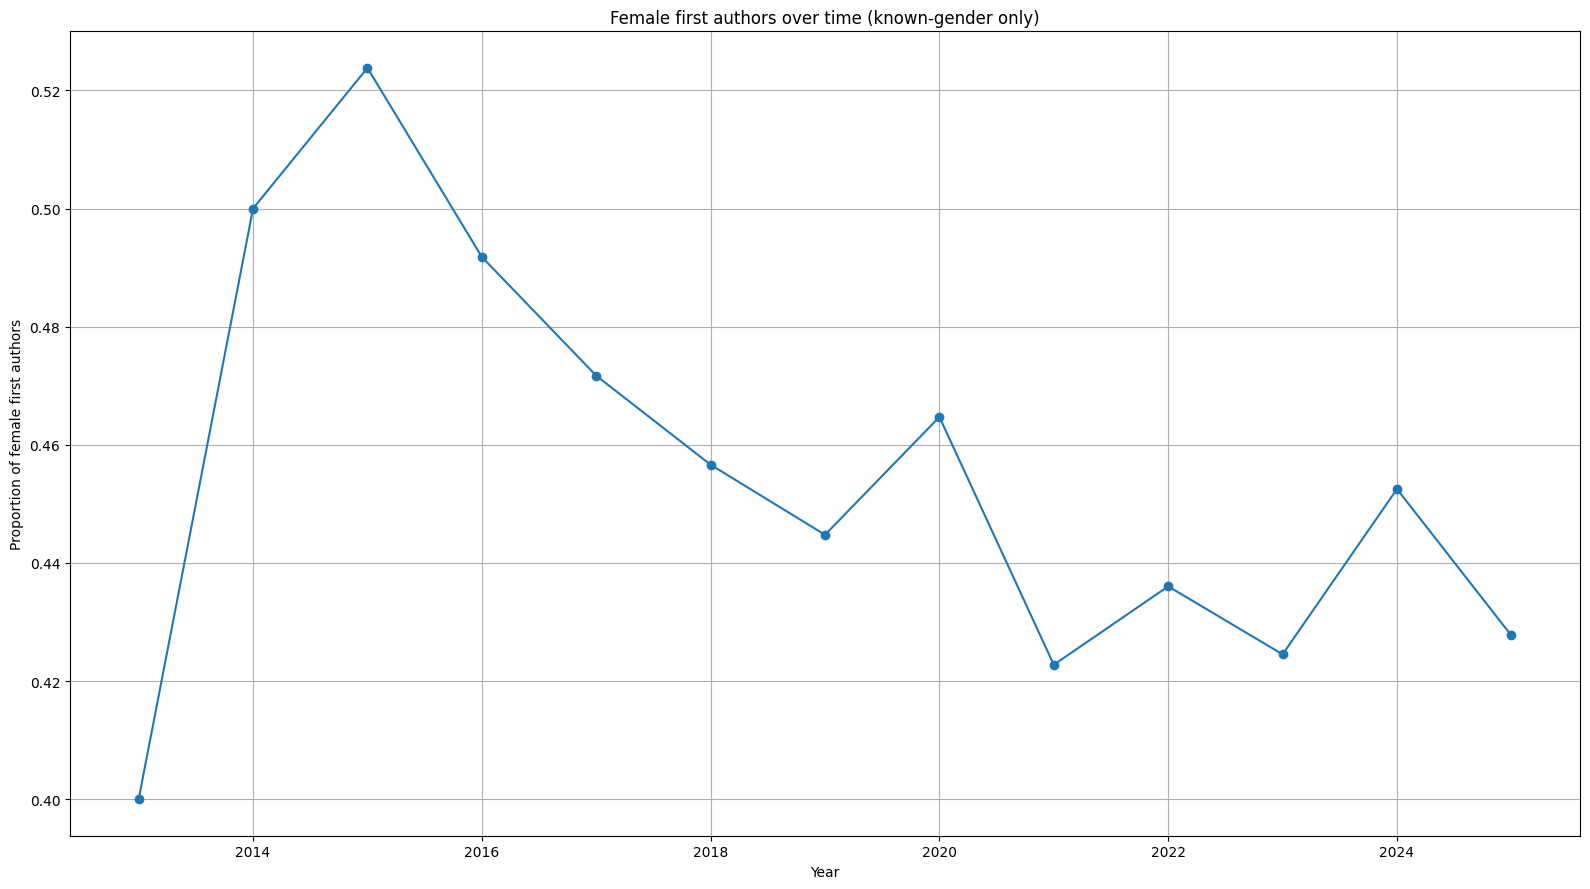


All-author counts by year (known-gender only):


gender,female,male,total
year,,,
2016,277,479,756
2017,388,755,1143
2018,888,1660,2548
2019,1442,2625,4067
2020,1843,3335,5178
2021,2815,4993,7808
2022,2978,5189,8167
2023,3159,4851,8010
2024,3942,6616,10558


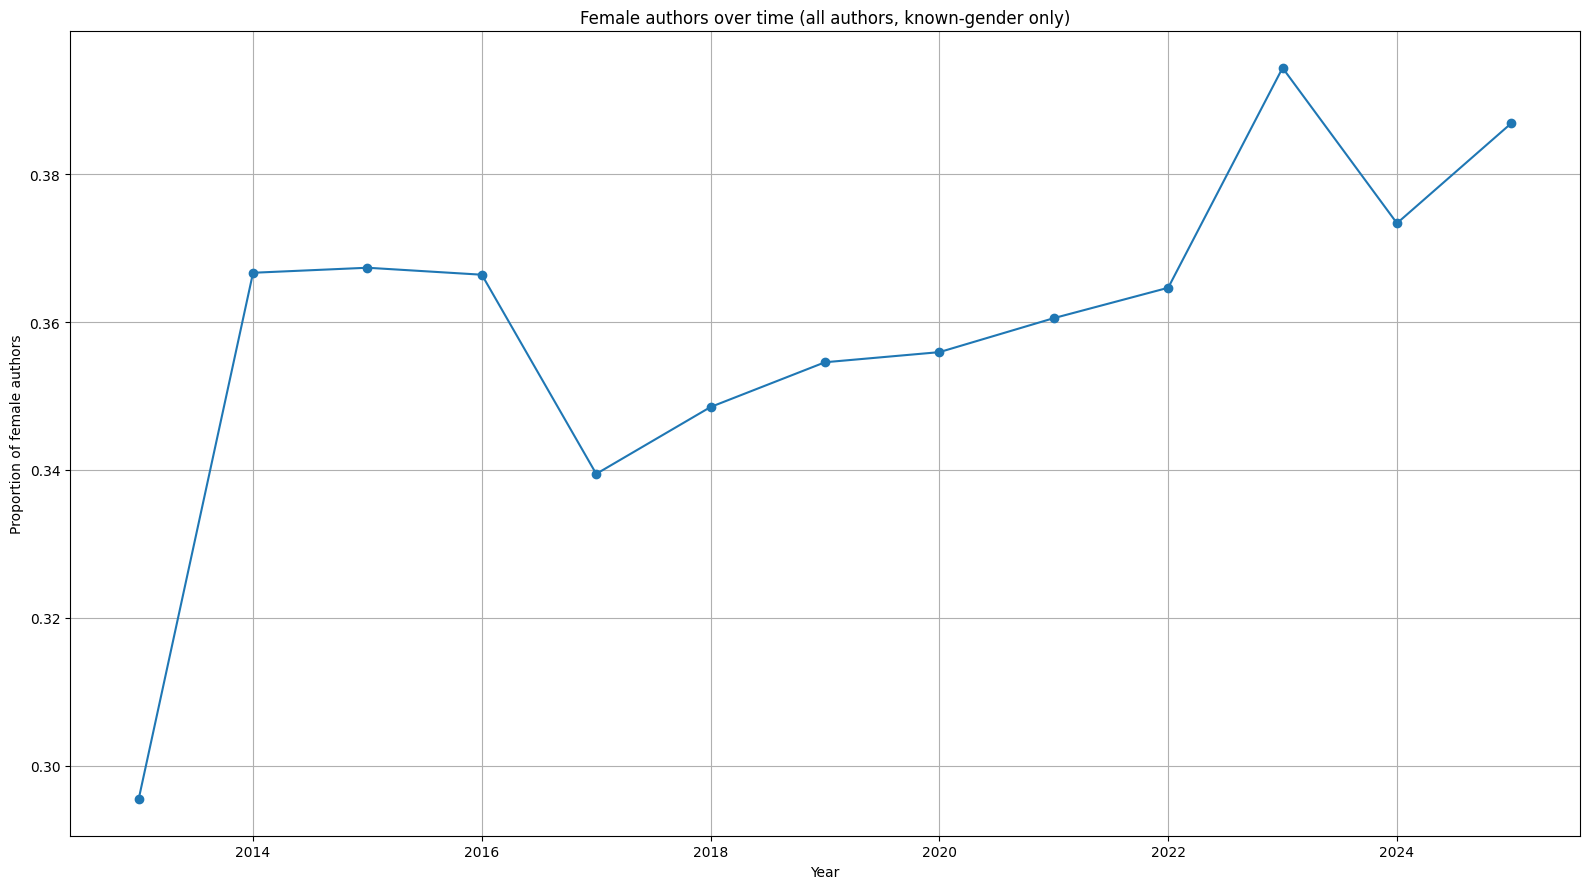


Corresponding-author counts by year (known-gender only):


gender,female,male,total
year,,,
2016,16,40,56
2017,47,60,107
2018,87,151,238
2019,138,252,390
2020,214,388,602
2021,307,604,911
2022,333,596,929
2023,346,630,976
2024,433,850,1283


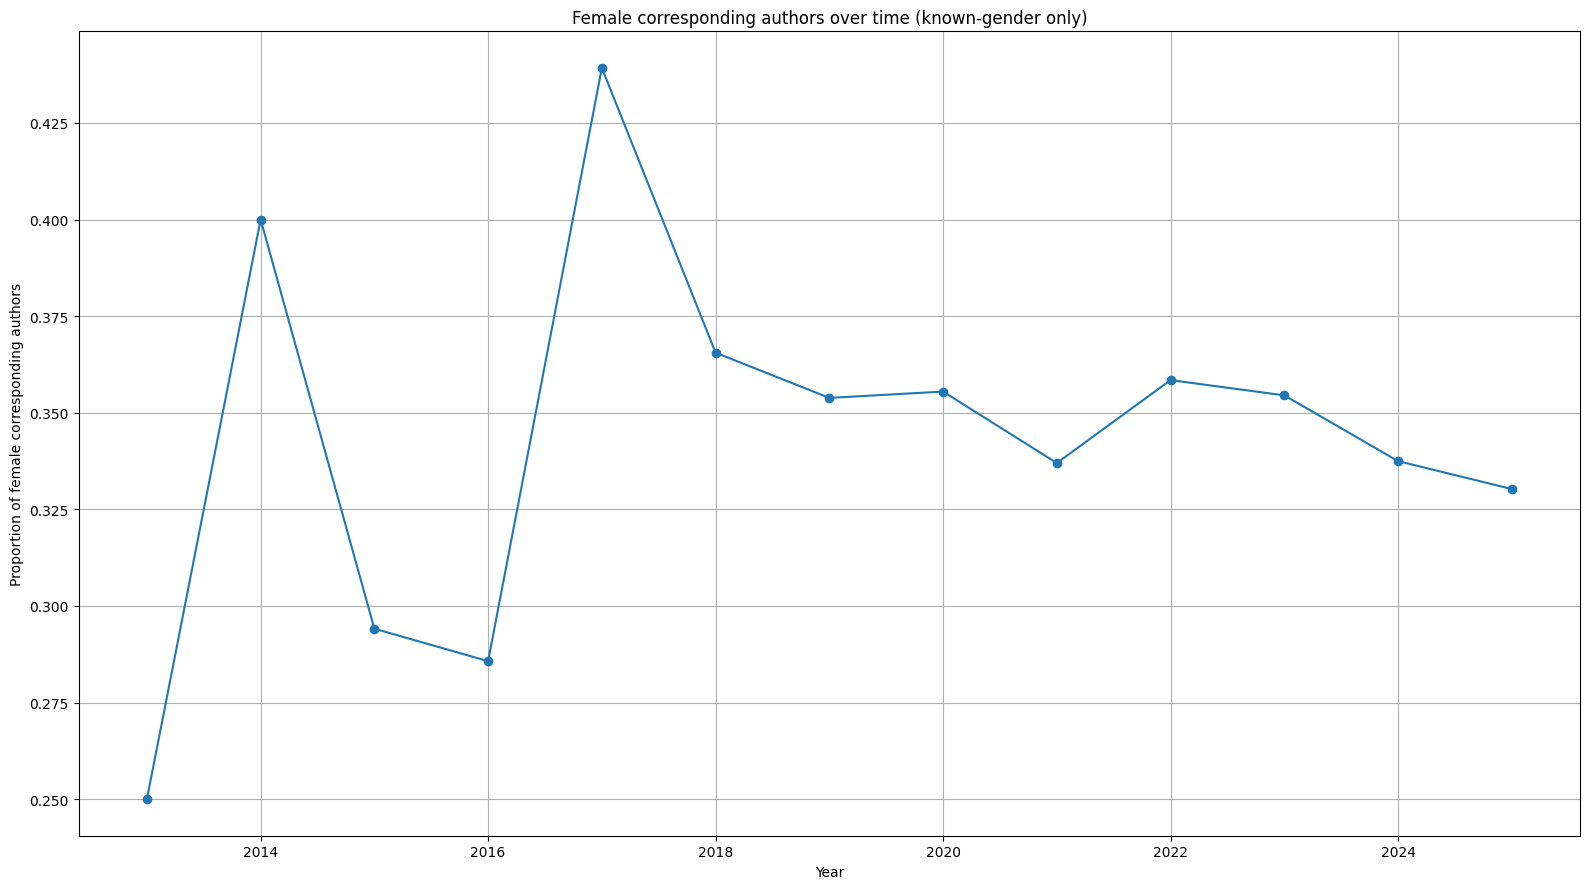


Using 'category_for_2020' as the domain column.

Sample of parsed domains:


,id,category_for_2020,domain
0,pub.1142697354,"[{'id': '80003', 'name': '32 Biomedical and Cl...",32 Biomedical and Clinical Sciences
0,pub.1142697354,"[{'id': '80003', 'name': '32 Biomedical and Cl...",3212 Ophthalmology and Optometry
1,pub.1107515670,"[{'id': '80137', 'name': '4202 Epidemiology'},...",4202 Epidemiology
1,pub.1107515670,"[{'id': '80137', 'name': '4202 Epidemiology'},...",4206 Public Health
1,pub.1107515670,"[{'id': '80137', 'name': '4202 Epidemiology'},...",42 Health Sciences



Top domains for FEMALE authors:


domain
32 Biomedical and Clinical Sciences             12697
42 Health Sciences                               6866
31 Biological Sciences                           5936
3105 Genetics                                    5377
3202 Clinical Sciences                           4771
4202 Epidemiology                                4156
52 Psychology                                    2045
4206 Public Health                               1871
3201 Cardiovascular Medicine and Haematology     1812
5202 Biological Psychology                       1746
Name: count, dtype: int64

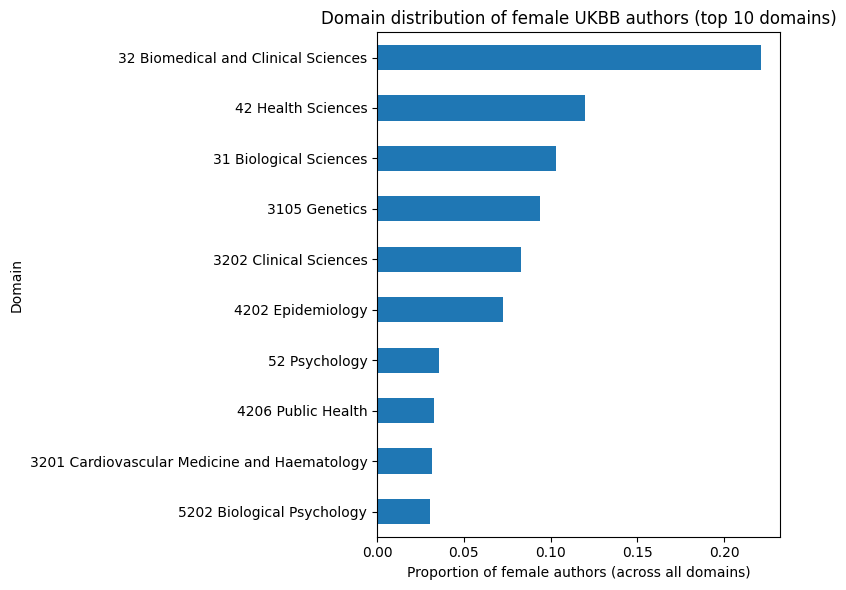


Top domains for MALE authors:


domain
32 Biomedical and Clinical Sciences             21050
42 Health Sciences                              11638
31 Biological Sciences                          10545
3105 Genetics                                    9594
3202 Clinical Sciences                           8342
4202 Epidemiology                                7084
3201 Cardiovascular Medicine and Haematology     3390
52 Psychology                                    3354
5202 Biological Psychology                       2893
4206 Public Health                               2754
Name: count, dtype: int64

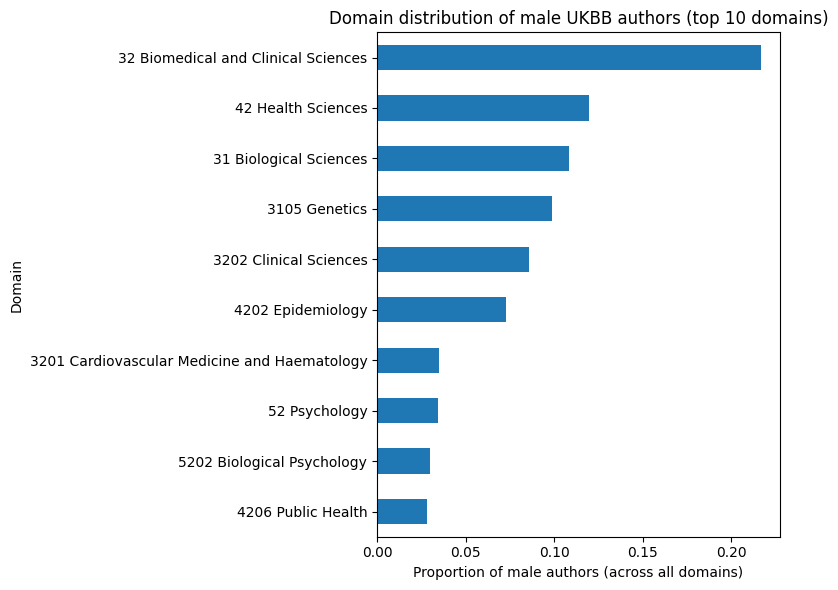

In [5]:

# ----------------------------------------------------------------------
# 1. Parse Dimensions-style authors
# ----------------------------------------------------------------------
if 'authors' not in df.columns or 'year' not in df.columns or 'id' not in df.columns:
    raise ValueError("Need columns 'authors', 'year', and 'id' in df.")

def parse_authors_dim(value):

    if pd.isna(value):
        return []

    s = str(value).strip()
    if not s or s == '[]':
        return []

    try:
        parsed = literal_eval(s)
    except Exception:
        # If malformed, skip
        return []

    authors = []
    if isinstance(parsed, list):
        for a in parsed:
            if isinstance(a, dict):
                first = str(a.get('first_name', '')).strip()
                last = str(a.get('last_name', '')).strip()
                corr_raw = a.get('corresponding', False)
                # Treat truthy values (True, 'True', etc.) as corresponding
                corresponding = bool(corr_raw) and str(corr_raw).lower() not in ['false', '0', 'no', 'none']
                if first or last:
                    authors.append({
                        'first_name': first,
                        'last_name': last,
                        'corresponding': corresponding
                    })
    return authors

rows = []
for _, row in df[['id', 'year', 'authors']].iterrows():
    paper_id = row['id']
    year = row['year']
    if pd.isna(year):
        continue
    try:
        year = int(year)
    except Exception:
        continue

    parsed_authors = parse_authors_dim(row['authors'])
    for pos, a in enumerate(parsed_authors):
        rows.append({
            'id': paper_id,
            'year': year,
            'author_position': pos,       # 0 = first author
            'first_name': a['first_name'],
            'last_name': a['last_name'],
            'corresponding': a['corresponding']
        })

authors_long = pd.DataFrame(rows)
print("\nAuthors long table (first rows):")
display(authors_long.head())
print("\nTotal authors parsed:", len(authors_long))

# ----------------------------------------------------------------------
# 2. Infer gender with gender-guesser (first token of first_name)
# ----------------------------------------------------------------------
detector = gender.Detector(case_sensitive=False)

def infer_gender(first_name):
    if not isinstance(first_name, str):
        return 'unknown'
    first_name = first_name.strip()
    if not first_name:
        return 'unknown'

    # Use first token only for things like "Maria C", "Laura D"
    token = first_name.split()[0]

    g = detector.get_gender(token)
    if g in ['male', 'mostly_male']:
        return 'male'
    if g in ['female', 'mostly_female']:
        return 'female'
    return 'unknown'

authors_long['gender'] = authors_long['first_name'].apply(infer_gender)

print("\nGender distribution (all years, all authors):")
display(authors_long['gender'].value_counts())

authors_long = authors_long.dropna(subset=['year'])
authors_long['year'] = authors_long['year'].astype(int)

# ----------------------------------------------------------------------
# 3. Female FIRST AUTHORS over time (known gender only)
# ----------------------------------------------------------------------
first_authors = authors_long[authors_long['author_position'] == 0].copy()
known_first = first_authors[first_authors['gender'].isin(['male', 'female'])].copy()

fa_counts = (
    known_first
    .groupby(['year', 'gender'])
    .agg(n=('id', 'count'))
    .reset_index()
)

fa_pivot = fa_counts.pivot(index='year', columns='gender', values='n').fillna(0)
fa_pivot['total'] = fa_pivot.sum(axis=1)
fa_pivot['prop_female'] = fa_pivot.get('female', 0) / fa_pivot['total']

print("\nFirst-author counts by year (known-gender only):")
display(fa_pivot[['female', 'male', 'total']].tail(10))

plt.figure()
plt.plot(fa_pivot.index, fa_pivot['prop_female'], marker='o')
plt.xlabel('Year')
plt.ylabel('Proportion of female first authors')
plt.title('Female first authors over time (known-gender only)')
plt.grid(True)
plt.tight_layout()
plt.savefig("ukbb_female_first_authors_over_time.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 4. Female ALL AUTHORS over time (known gender only)
# ----------------------------------------------------------------------
known_all = authors_long[authors_long['gender'].isin(['male', 'female'])].copy()

all_counts = (
    known_all
    .groupby(['year', 'gender'])
    .agg(n=('id', 'count'))
    .reset_index()
)

all_pivot = all_counts.pivot(index='year', columns='gender', values='n').fillna(0)
all_pivot['total'] = all_pivot.sum(axis=1)
all_pivot['prop_female'] = all_pivot.get('female', 0) / all_pivot['total']

print("\nAll-author counts by year (known-gender only):")
display(all_pivot[['female', 'male', 'total']].tail(10))

plt.figure()
plt.plot(all_pivot.index, all_pivot['prop_female'], marker='o')
plt.xlabel('Year')
plt.ylabel('Proportion of female authors')
plt.title('Female authors over time (all authors, known-gender only)')
plt.grid(True)
plt.tight_layout()
plt.savefig("ukbb_female_all_authors_over_time.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 5. Female CORRESPONDING AUTHORS over time (known gender only)
# ----------------------------------------------------------------------
corr_authors = authors_long[
    (authors_long['corresponding'] == True) &
    (authors_long['gender'].isin(['male', 'female']))
].copy()

corr_counts = (
    corr_authors
    .groupby(['year', 'gender'])
    .agg(n=('id', 'count'))
    .reset_index()
)

if corr_counts.empty:
    print("\nNo corresponding authors found (or 'corresponding' flag not recognised).")
else:
    corr_pivot = corr_counts.pivot(index='year', columns='gender', values='n').fillna(0)
    corr_pivot['total'] = corr_pivot.sum(axis=1)
    corr_pivot['prop_female'] = corr_pivot.get('female', 0) / corr_pivot['total']

    print("\nCorresponding-author counts by year (known-gender only):")
    display(corr_pivot[['female', 'male', 'total']].tail(10))

    plt.figure()
    plt.plot(corr_pivot.index, corr_pivot['prop_female'], marker='o')
    plt.xlabel('Year')
    plt.ylabel('Proportion of female corresponding authors')
    plt.title('Female corresponding authors over time (known-gender only)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("ukbb_female_corresponding_authors_over_time.png", dpi=300)
    plt.show()

# ----------------------------------------------------------------------
# 6. Domain extraction for overall distribution plots
# ----------------------------------------------------------------------

domain_col = None
for cand in ['category_for_2020', 'category_for', 'category_uoa', 'category_sdg']:
    if cand in df.columns:
        domain_col = cand
        break

if domain_col is None:
    raise ValueError("No suitable domain column found (tried category_for_2020, category_for, category_uoa, category_sdg).")

print(f"\nUsing '{domain_col}' as the domain column.")

def parse_domains(value):
    """
    Parse a Dimensions-style category field, which is often a list of dicts.
    Tries to extract human-readable domain names.
    """
    if pd.isna(value):
        return []

    s = str(value).strip()
    if not s or s == '[]':
        return []

    try:
        parsed = literal_eval(s)
    except Exception:
        # Fallback: if it's a plain string or semi-structured, treat as single label
        return [s]

    domains = []
    if isinstance(parsed, list):
        for item in parsed:
            if isinstance(item, dict):
                # Try common keys for names
                for key in ['name', 'title', 'field_name', 'researcher_field']:
                    if key in item and item[key]:
                        domains.append(str(item[key]).strip())
                        break
                else:
                    # If no known key, just use the whole dict as string
                    domains.append(str(item))
            else:
                domains.append(str(item).strip())
    else:
        domains.append(str(parsed).strip())

    return [d for d in domains if d]

paper_domains = df[['id', domain_col]].copy()
paper_domains['domain_list'] = paper_domains[domain_col].apply(parse_domains)
paper_domains = paper_domains.explode('domain_list').rename(columns={'domain_list': 'domain'})
paper_domains = paper_domains.dropna(subset=['domain'])

print("\nSample of parsed domains:")
display(paper_domains.head())

# Join domains onto author-level data
authors_with_domains = authors_long.merge(
    paper_domains[['id', 'domain']],
    on='id',
    how='left'
)


awd_known = authors_with_domains[authors_with_domains['gender'].isin(['female', 'male'])].copy()

# ----------------------------------------------------------------------
# 7. Horizontal bar chart: domains for FEMALE authors (all years, top 10)
# ----------------------------------------------------------------------
female_domains = awd_known[awd_known['gender'] == 'female'].copy()
female_domain_counts = female_domains['domain'].value_counts()

top_n = 10
female_top = female_domain_counts.head(top_n)
female_top_prop = female_top / female_domain_counts.sum()

print("\nTop domains for FEMALE authors:")
display(female_top)

plt.figure(figsize=(8, 6))
female_top_prop.sort_values().plot(kind='barh')
plt.xlabel('Proportion of female authors (across all domains)')
plt.ylabel('Domain')
plt.title('Domain distribution of female UKBB authors (top 10 domains)')
plt.tight_layout()
plt.savefig("ukbb_female_domain_distribution_top10.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 8. Horizontal bar chart: domains for MALE authors (all years, top 10)
# ----------------------------------------------------------------------
male_domains = awd_known[awd_known['gender'] == 'male'].copy()
male_domain_counts = male_domains['domain'].value_counts()

male_top = male_domain_counts.head(top_n)
male_top_prop = male_top / male_domain_counts.sum()

print("\nTop domains for MALE authors:")
display(male_top)

plt.figure(figsize=(8, 6))
male_top_prop.sort_values().plot(kind='barh')
plt.xlabel('Proportion of male authors (across all domains)')
plt.ylabel('Domain')
plt.title('Domain distribution of male UKBB authors (top 10 domains)')
plt.tight_layout()
plt.savefig("ukbb_male_domain_distribution_top10.png", dpi=300)
plt.show()

